In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


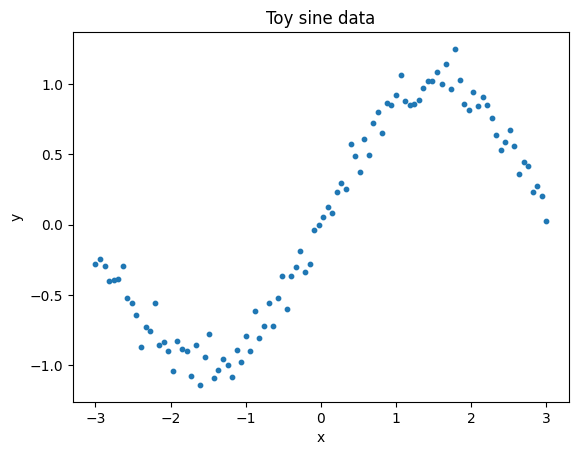

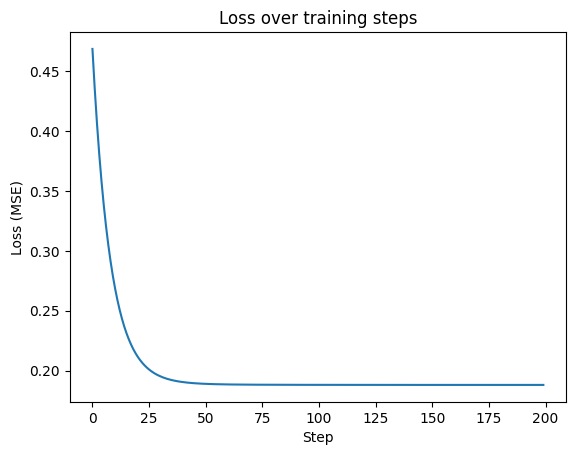

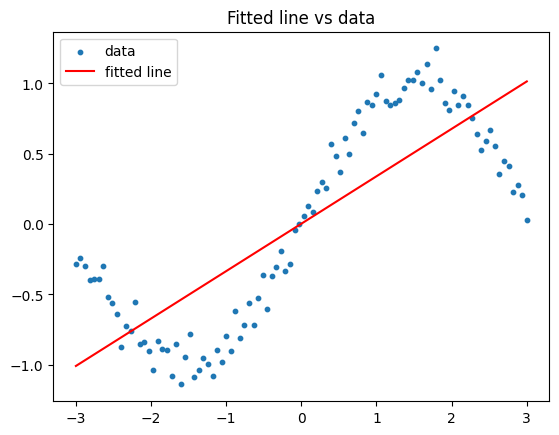

In [3]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy sine data")
plt.show()

w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.01
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)


plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss over training steps")
plt.show()

plt.scatter(x, y, s=10, label="data")
plt.plot(x, w * x + b, color="red", label="fitted line")
plt.legend()
plt.title("Fitted line vs data")
plt.show()

Yes the derivation matches the code directly.
dw = np.mean(2 * (y_hat - y) * x)
db = np.mean(2 * (y_hat - y))

This is underfitting.
Overfitting means the model is complex enough to chase the noise in the training data, giving low training loss but poor generalization. That's not what's happening here the training loss itself plateaus at a high value and never gets low, no matter how long it is trained.
A single neuron with no nonlinearity computes ŷ = w·x + b, as the equation of a straight line. The entire set of functions this model can ever represent is "all possible straight lines." A sine wave is periodic and non-monotonic (it goes up, then down, then up again), and no straight line can capture that shape not for any values of w and b.
Gradient descent isn't the limitation here. It successfully finds the best straight line that's why the loss curve flattens out. But the "best line" is still a terrible fit to a curve, because the model's hypothesis space (the family of functions it can represent) doesn't contain anything resembling a sine wave. Training longer only gets you closer to the best line already available; it can't expand what shapes are available to fit. That's the hallmark of underfitting caused by insufficient model capacity, not insufficient training.